# 实验2 线性分类器

## 读取MNIST数据集，并将其划分为train/val/test数据集

### MNIST数据集读取

In [1]:
import gzip
import os
import struct
import numpy as np

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels), 784)

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):
    
    total_len = images.shape[0]
    offset = int(total_len * ratio)
    
    val_img = images[:offset][:]
    val_lb = labels[:offset]
    
    train_img = images[offset:][:]
    train_lb = labels[offset:]
    
    return train_img, train_lb, val_img, val_lb    

### 按照 5:1:1 划分为训练集，验证集，测试集


In [2]:
[images, labels] = load_mnist('../MNIST', kind='train')
[test_img, test_lb] = load_mnist('../MNIST', kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)

# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape)

训练集图像格式为: (50000, 784) 训练集标签格式为: (50000,)
验证集图像格式为: (10000, 784) 验证集标签格式为: (10000,)
测试集图像格式为: (10000, 784) 测试集标签格式为: (10000,)


## 用Random Search + Cross Entroy Loss来训练Linear Classifier

### 用向量化计算Cross Entroy Loss

In [3]:
def vectorized_loss_softmax(X, y, W):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=50000 examples.
    
    Inputs:
    - W: Indexs of linear classifier, a numpy array of shape (D, C) containing weights.
    - X: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - y: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
         that X[i] has label c, where 0 <= c < C.
    
    Returns a tuple of:
    - Softmax loss as single float.
    """
    
    # set the value of delta, lamda
    delta = 1.0
    lamda = 1.0
    num_train = X.shape[0]
    num_class = W.shape[1]
    
    # scores: class x examples
    scores = W.T.dot(X.T).reshape(num_class, num_train)
    
    # scores_max: 1 x examples, get the max value from each column
    scores_max = np.reshape(np.max(scores, axis=0), (1, num_train))

    # prob: class x examples, calculate the log probability
    # use scores_max to limit the boundary of exp indexes
    prob = np.exp(scores-scores_max) / np.sum(np.exp(scores-scores_max), axis=0)

    # set value 1 in true label positions, 0 for false labels
    y_true = np.zeros(prob.shape)
    y_true[y, np.arange(num_train)] = 1.0
    
    # calculate the average data loss
    loss = -np.sum(y_true * np.log(prob))/num_train
    
    return loss

### 定义训练函数

In [4]:
def random_search(X, y):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=50000 examples.
    
    Inputs:
    - X: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - y: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
         that X[i] has label c, where 0 <= c < C.
    
    Returns:
    - Best indexs W
    """

    X = X / 255.0
    
    # sign the highest float value to best loss
    best_loss = float('inf')

    acc_history = []
    loss_history = []
    
    # randomly choose different indexs W to calculate the loss
    for num in range(100):
        # W: dimension x class
        W = np.random.randn(X.shape[1], 10) * 0.001
        loss = vectorized_loss_softmax(X, y, W)
        loss_history.append(loss)
            
        # scores: class x examples
        scores =  W.T.dot(X.T)
        
        # get the predicted labels
        # y_pred: examples
        y_pred = np.argmax(scores, axis=0)
        
        # calculate the accuracy
        accuracy = np.mean(y_pred == y)*100
        acc_history.append(accuracy)
        
        # update the best loss
        if loss < best_loss:
            best_loss = loss
            best_W = W
            best_acc = accuracy
    

        # print the result for every iteration
        print("Epoch: %d  Loss: %.3f  Acc: %.3f%%  Best Loss: %.3f  Best Acc: %.3f%%" % (num+1, loss, accuracy, best_loss, best_acc))
    
    # print the final result
    print("\nBest Loss: %.3f  Best Acc: %.3f%%" % (best_loss, best_acc))
    
    return best_W, acc_history, loss_history

### 在训练集上进行训练

In [5]:
# train the linear classifier with random search strategy

best_W, acc_history, loss_history = random_search(train_img, train_lb)

Epoch: 1  Loss: 2.301  Acc: 8.054%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 2  Loss: 2.304  Acc: 4.448%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 3  Loss: 2.303  Acc: 11.578%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 4  Loss: 2.302  Acc: 12.166%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 5  Loss: 2.302  Acc: 12.724%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 6  Loss: 2.303  Acc: 8.076%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 7  Loss: 2.302  Acc: 11.728%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 8  Loss: 2.303  Acc: 10.984%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 9  Loss: 2.302  Acc: 9.836%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 10  Loss: 2.302  Acc: 7.498%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 11  Loss: 2.302  Acc: 12.690%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 12  Loss: 2.301  Acc: 14.634%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 13  Loss: 2.302  Acc: 12.800%  Best Loss: 2.301  Best Acc: 8.054%
Epoch: 14  Loss: 2.303  Acc: 10.832%  Best Loss: 2.301  Best Acc:

### 绘制训练精度的曲线

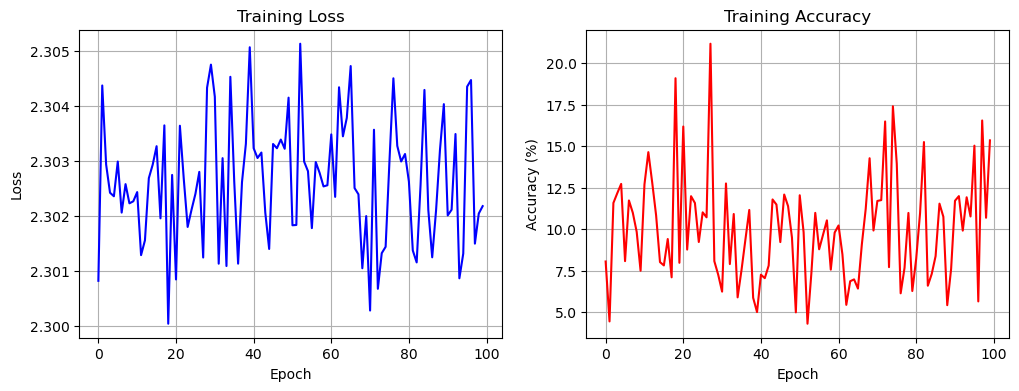

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(acc_history, 'r-')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')
plt.grid(True)

plt.show()


### 在验证集上测试分类的效果

In [7]:
# test the classification accuracy on validation dataset

# scores: class x examples
scores =  best_W.T.dot(val_img.T)

# get the predicted labels
# y_pred: examples
y_pred = np.argmax(scores, axis=0)

# calculate the accuracy
accuracy = np.mean(y_pred == val_lb)*100

# print the accuracy
print("Random Search在验证集上的分类精度 为: %.3f%%" % accuracy)

Random Search在验证集上的分类精度 为: 19.260%


实验结果：训练过程中损失值稳定在 2.30 左右，精度在 4% ~ 21% 之间波动，最终最佳验证精度达到 19.26%（略高于随机猜测的10%），并且精度没有上升趋势  
结果分析：由于随机搜索算法每一次循环都选择一个随机的W进行计算，则精确率一直在上下波动

### 三层神经网络

In [8]:
def random_search_ReLu(X, y):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=50000 examples.
    
    Inputs:
    - X: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - y: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
         that X[i] has label c, where 0 <= c < C.
    
    Returns:
    - Best indexs W
    """

    X = X / 255.0
    
    # sign the highest float value to best loss
    best_loss = float('inf')

    acc_history = []
    loss_history = []
    
    # randomly choose different indexs W to calculate the loss
    for num in range(100):
        # W: dimension x class
        W = np.random.randn(X.shape[1], 128) * 0.001
        W1 = np.random.randn(128, 64) * 0.001
        W2 = np.random.randn(64, 10) * 0.001

        h1 = np.dot(X, W)
        r1 = np.maximum(0, h1)

        h2 = np.dot(r1, W1)
        r2 = np.maximum(0, h2)

        out = np.dot(r2, W2)

        scores_max = np.max(out, axis=1, keepdims=True)
        scores = out - scores_max
        exp_scores = np.exp(scores)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

        loss = np.mean(-np.log(probs[np.arange(X.shape[0]),y]))
        loss_history.append(loss)
        
        # get the predicted labels
        # y_pred: examples
        y_pred = np.argmax(out, axis=1)
        
        # calculate the accuracy
        accuracy = np.mean(y_pred == y)*100
        acc_history.append(accuracy)
        
        # update the best loss
        if loss < best_loss:
            best_loss = loss
            best_W = W
            best_W1 = W1
            best_W2 = W2
            best_acc = accuracy
    

        # print the result for every iteration
        print("Epoch: %d  Loss: %.3f  Acc: %.3f%%  Best Loss: %.3f  Best Acc: %.3f%%" % (num+1, loss, accuracy, best_loss, best_acc))
    
    # print the final result
    print("\nBest Loss: %.3f  Best Acc: %.3f%%" % (best_loss, best_acc))
    
    return best_W, best_W1, best_W2, acc_history, loss_history

### 在训练集上进行训练

In [9]:
# train the linear classifier with random search strategy
best_W_r, best_W1_r, best_W2_r, acc_history_r, loss_history_r = random_search_ReLu(train_img, train_lb)

Epoch: 1  Loss: 2.303  Acc: 12.972%  Best Loss: 2.303  Best Acc: 12.972%
Epoch: 2  Loss: 2.303  Acc: 7.606%  Best Loss: 2.303  Best Acc: 12.972%
Epoch: 3  Loss: 2.303  Acc: 8.194%  Best Loss: 2.303  Best Acc: 12.972%
Epoch: 4  Loss: 2.303  Acc: 6.830%  Best Loss: 2.303  Best Acc: 12.972%
Epoch: 5  Loss: 2.303  Acc: 10.058%  Best Loss: 2.303  Best Acc: 12.972%
Epoch: 6  Loss: 2.303  Acc: 16.972%  Best Loss: 2.303  Best Acc: 12.972%
Epoch: 7  Loss: 2.303  Acc: 11.138%  Best Loss: 2.303  Best Acc: 12.972%
Epoch: 8  Loss: 2.303  Acc: 8.122%  Best Loss: 2.303  Best Acc: 8.122%
Epoch: 9  Loss: 2.303  Acc: 8.704%  Best Loss: 2.303  Best Acc: 8.122%
Epoch: 10  Loss: 2.303  Acc: 8.050%  Best Loss: 2.303  Best Acc: 8.122%
Epoch: 11  Loss: 2.303  Acc: 8.510%  Best Loss: 2.303  Best Acc: 8.122%
Epoch: 12  Loss: 2.303  Acc: 12.022%  Best Loss: 2.303  Best Acc: 12.022%
Epoch: 13  Loss: 2.303  Acc: 10.026%  Best Loss: 2.303  Best Acc: 12.022%
Epoch: 14  Loss: 2.303  Acc: 13.230%  Best Loss: 2.303  Be

### 绘制训练精度的曲线

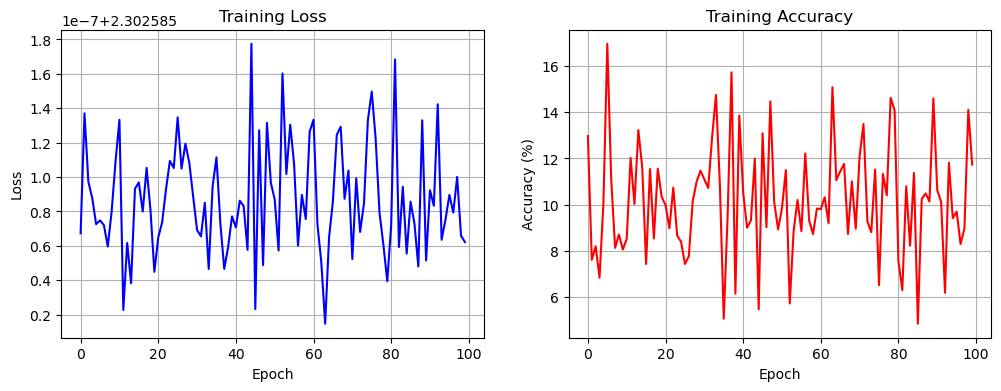

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history_r, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(acc_history_r, 'r-')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')
plt.grid(True)

plt.show()

### 在验证集上测试分类的效果

In [11]:
# test the classification accuracy on validation dataset

# scores: class x examples
h1_r =  best_W_r.T.dot(val_img.T)
r1_r = np.maximum(0, h1_r)
h2_r = best_W1_r.T.dot(r1_r)
r2_r = np.maximum(0, h2_r)
scores_r = best_W2_r.T.dot(r2_r)

# get the predicted labels
# y_pred: examples
y_pred_r = np.argmax(scores_r, axis=0)

# calculate the accuracy
accuracy_r = np.mean(y_pred_r == val_lb)*100

# print the accuracy
print("Random Search + ReLU在验证集上的分类精度 为: %.3f%%" % accuracy_r)

Random Search + ReLU在验证集上的分类精度 为: 14.570%


实验结果：添加两层ReLU后，损失值依然稳定在 2.303 左右，精度在 5% ~ 16% 之间波动，最佳验证精度为 14.57%，与线性分类器相比无明显提升  
结果分析：在增加两层ReLu后，由于本质上还是随机搜索，所以精确度并没有明显上升

## 使用梯度下降法，训练线性分类器

### 定义训练函数
手动计算梯度  

使用梯度下降法更新参数

线性分类器没有激活函数

损失函数使用L2

In [12]:
import numpy as np

class LinearClassifier:
    def __init__(self, input_dim, num_classes):
        
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros((1, num_classes))

    def forward(self, X):
        # 线性映射
        return np.dot(X, self.W) + self.b

    def compute_loss(self, y_pred, y_true):
        """使用 L2 Loss (均方误差)"""
        
        # 将标签转为 One-hot 编码以计算 L2
        num_classes = y_pred.shape[1]
        y_onehot = np.eye(num_classes)[y_true]
        
        loss = 0.5 * np.mean(np.sum((y_pred - y_onehot)**2, axis=1))
        return loss, y_onehot

    def train_step(self, X, y_true, learning_rate):
        X = X / 255.0
        num_samples = X.shape[0]
        
        # 1. 前向传播
        y_pred = self.forward(X)
        
        # 2. 计算损失和 One-hot 标签
        loss, y_onehot = self.compute_loss(y_pred, y_true)
        
        # 3. 反向传播 (手动计算梯度)
        # dL/dy_pred = (y_pred - y_onehot) / n
        grad_y = (y_pred - y_onehot) / num_samples
        
        grad_W = np.dot(X.T, grad_y)
        grad_b = np.sum(grad_y, axis=0, keepdims=True)
        
        # 4. 参数更新 (梯度下降)
        self.W -= learning_rate * grad_W
        self.b -= learning_rate * grad_b
        
        return loss

    def predict(self, X):
        X = X / 255.0
        scores = self.forward(X)
        return np.argmax(scores, axis=1)

def evaluate(model, X, y):
    predictions = model.predict(X)
    accuracy = np.mean(predictions == y)
    return accuracy


In [13]:
input_size = 784
num_classes = 10
lr = 0.05
epochs = 200

model = LinearClassifier(input_size, num_classes)

print("开始训练...")
for epoch in range(epochs):
    
    loss = model.train_step(train_img, train_lb, lr)
    
    if (epoch + 1) % 5 == 0:
        val_acc = evaluate(model, test_img, test_lb)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}, Val Acc: {val_acc:.4f}")

print("训练完成！")

开始训练...
Epoch [5/200], Loss: 0.3739, Val Acc: 0.6696
Epoch [10/200], Loss: 0.3079, Val Acc: 0.7400
Epoch [15/200], Loss: 0.2778, Val Acc: 0.7925
Epoch [20/200], Loss: 0.2607, Val Acc: 0.8010
Epoch [25/200], Loss: 0.2500, Val Acc: 0.8174
Epoch [30/200], Loss: 0.2426, Val Acc: 0.8186
Epoch [35/200], Loss: 0.2374, Val Acc: 0.8271
Epoch [40/200], Loss: 0.2335, Val Acc: 0.8307
Epoch [45/200], Loss: 0.2304, Val Acc: 0.8357
Epoch [50/200], Loss: 0.2280, Val Acc: 0.8380
Epoch [55/200], Loss: 0.2259, Val Acc: 0.8407
Epoch [60/200], Loss: 0.2242, Val Acc: 0.8419
Epoch [65/200], Loss: 0.2227, Val Acc: 0.8444
Epoch [70/200], Loss: 0.2214, Val Acc: 0.8450
Epoch [75/200], Loss: 0.2203, Val Acc: 0.8454
Epoch [80/200], Loss: 0.2192, Val Acc: 0.8458
Epoch [85/200], Loss: 0.2183, Val Acc: 0.8475
Epoch [90/200], Loss: 0.2174, Val Acc: 0.8484
Epoch [95/200], Loss: 0.2166, Val Acc: 0.8498
Epoch [100/200], Loss: 0.2159, Val Acc: 0.8504
Epoch [105/200], Loss: 0.2152, Val Acc: 0.8524
Epoch [110/200], Loss: 0.

### 在验证集上测试分类的效果

In [14]:
val_acc = evaluate(model, val_img, val_lb)
print(f"验证集上的分类精度为: {val_acc:.4f}")

验证集上的分类精度为: 0.8542


实验结果：使用梯度下降法，学习率设为 0.05，经过 200 轮迭代后，训练损失从初始值平稳下降至 0.2074，验证精度最终达到 85.42%  
结果分析：梯度下降法进行训练的线性分类器原本的学习率为0.1过大，导致损失一直剧烈上升直至超出整型数据；如果调得较小，则收敛速度太慢，需要更长时间更多迭代次数。将其调整修改至0.05能最快降低损失、提升精确率，解决了损失爆炸式增长的问题，最终验证集的分类精确率能达到85.42%，优化效果好

# 要求
## 1.把上面的程序补充完整，画出训练过程中训练精度
## 2.分类器前再增加2层（三层神经网络）使用Relu激活函数，画出训练精度，分析结果
## 3.上面使用梯度下降法训练线性分类器，效果似乎并不好，对齐进行优化。

# 评分标准：
### ipynb导出PDF，提交作业。
### 代码尽量简洁高效，不包含实验题目无关的函数、代码，加分
### 课上能够完成加分
### 实验结果完整、格式规范、加分
### 图文并茂、实验结果分析有自己的想法，加分
### 